# The Acquisition Score
| # | Question |
|---|---|
| 1 | What should the score reward — and what evidence earned each component its place? |
| 2 | What does the ranking say, and does it survive a sanity read? |
| 3 | Is the ranking an artefact of my chosen weights? |
| 4 | What *kind* of game is each one — and whose negativity wouldn't transfer to a new owner? |

**Inputs:** `data/reviews_prepared.csv` (Step 1), `data/nlp_game_signals.csv` (Step 3)
**Outputs:** `data/acquisition_scorecard.csv` (the dashboard's spine), charts in `figures/`


## 0. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import spearmanr

DATA_PATH = 'data/reviews_prepared.csv'
NLP_PATH  = 'data/nlp_game_signals.csv'
FIG_DIR = 'figures'; os.makedirs(FIG_DIR, exist_ok=True)
SEED = 42

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 10})
C_POS, C_NEG, C_HI, C_MUT = '#2a9d8f', '#e76f51', '#e9c46a', '#9aa5b1'
COMP_COLORS = ['#2a9d8f', '#8ab17d', '#e9c46a', '#f4a261', '#e76f51', '#577590']

def save(fig, name):
    fig.savefig(f'{FIG_DIR}/{name}.png', bbox_inches='tight', dpi=150)
    print(f'saved figures/{name}.png')

df  = pd.read_csv(DATA_PATH, parse_dates=['date'])
sig = pd.read_csv(NLP_PATH, index_col='title_clean')
cutoff = df['date'].max()
print(f"{len(df):,} reviews | {df['title_clean'].nunique()} games | data ends {cutoff.date()}")

14,617 reviews | 23 games | data ends 2019-02-16


## Question 1 — What should the score reward?


| Component | Weight | Evidence that earned it |
|---|---|---|
| Overall positivity | 30% | the foundation — but Story 1 (Step 2) showed it must never be read through volume |
| Recent positivity (last 6 mo) | 20% | the client buys the game's *future*; recent sentiment beats ancient history |
| Review velocity (recent, log) | 15% | Story 4: current activity = current relevance on a new platform |
| Deep-player positivity (100h+) | 15% | Story 2 + Step 3 Q4: 49% of negatives come from 100h+ players — informed verdicts deserve extra weight |
| Sentiment stability | 10% | Story 3: lifetime averages lie when one quarter craters; steadiness is itself a signal |
| Engagement depth (median hours, log) | 10% | Story 2: devotion vs buzz — hours measure what players *did* |

Three small-sample rules, decided before computing anything (the table in Step 2's first look
warned us 5 games have ≤10 reviews):
- **Shrinkage:** a game's recent or deep-player positivity based on a handful of reviews is
  pulled toward its lifetime rate (Bayesian shrinkage, k=10). Nine recent reviews of Terraria,
  all positive, should *lean* recent — not count like Slay the Spire's 215.
- **Unmeasurable stability** (fewer than 3 quarters with ≥20 reviews — mostly new releases) is
  imputed at the catalogue median: neutral, neither rewarded nor punished, and flagged.
- **Confidence tiers** (from Step 1) ride alongside every score so a Low-confidence number can
  never masquerade as a High-confidence one.

In [2]:
# ---- per-game raw ingredients --------------------------------------------
recent = df[df['date'] >= cutoff - pd.Timedelta(days=180)]
prior  = df[(df['date'] <  cutoff - pd.Timedelta(days=180)) &
            (df['date'] >= cutoff - pd.Timedelta(days=360))]
pt   = df[df['use_playtime']]
deep = pt[pt['hour_played'] >= 100]

g = df.groupby('title_clean').agg(n=('rec', 'size'), pos=('rec', 'mean'),
                                  first=('date', 'min'), conf=('confidence_tier', 'first'))
g['age_days']   = (cutoff - g['first']).dt.days
g['recent_n']   = recent.groupby('title_clean').size().reindex(g.index).fillna(0).astype(int)
g['recent_pos'] = recent.groupby('title_clean')['rec'].mean().reindex(g.index)
g['prior_n']    = prior.groupby('title_clean').size().reindex(g.index).fillna(0).astype(int)
g['momentum']   = g['recent_n'] / g['prior_n'].replace(0, np.nan)   # NaN = new release
g['deep_n']     = deep.groupby('title_clean').size().reindex(g.index).fillna(0).astype(int)
g['deep_pos']   = deep.groupby('title_clean')['rec'].mean().reindex(g.index)
g['median_hours'] = pt.groupby('title_clean')['hour_played'].median().reindex(g.index)

# quarterly sentiment dispersion (quarters with >= 20 reviews; need >= 3 to measure)
qstd = {}
for t, sub in df.groupby('title_clean'):
    q = sub.set_index('date')['rec'].resample('QE').agg(n='size', pos='mean')
    q = q[q['n'] >= 20]
    qstd[t] = q['pos'].std() if len(q) >= 3 else np.nan
g['q_pos_std'] = pd.Series(qstd)
g['stability_unmeasured'] = g['q_pos_std'].isna()

# ---- small-sample rules ---------------------------------------------------
K = 10  # shrinkage: small samples pulled toward the game's lifetime rate
g['recent_pos_adj'] = (g['recent_pos'].fillna(g['pos'])*g['recent_n'] + g['pos']*K) / (g['recent_n'] + K)
g['deep_pos_adj']   = (g['deep_pos'].fillna(g['pos'])*g['deep_n']     + g['pos']*K) / (g['deep_n'] + K)
g['q_std_filled']   = g['q_pos_std'].fillna(g['q_pos_std'].median())

# ---- the six components, each scaled to 0–1 -------------------------------
def minmax(s): return (s - s.min()) / (s.max() - s.min())
comp = pd.DataFrame(index=g.index)
comp['overall_positivity']     = g['pos']
comp['recent_positivity']      = g['recent_pos_adj']
comp['review_velocity']        = minmax(np.log1p(g['recent_n']))
comp['deep_player_positivity'] = g['deep_pos_adj']
comp['sentiment_stability']    = 1 - minmax(g['q_std_filled'])
comp['engagement_depth']       = minmax(np.log1p(g['median_hours']))

WEIGHTS = {'overall_positivity': .30, 'recent_positivity': .20, 'review_velocity': .15,
           'deep_player_positivity': .15, 'sentiment_stability': .10, 'engagement_depth': .10}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9

g['score'] = sum(comp[c] * w for c, w in WEIGHTS.items()) * 100
print("Components computed for all", len(g), "games. Shrinkage k =", K)
print("Stability imputed at catalogue median for:",
      ', '.join(g[g['stability_unmeasured']].index[:5]) + ' …' if g['stability_unmeasured'].sum() > 5 else '')
comp.round(2)

Components computed for all 23 games. Shrinkage k = 10
Stability imputed at catalogue median for: ACE COMBAT 7: SKIES UNKNOWN, Beat Saber, Farming Simulator 19, Insurgency: Sandstorm, Left 4 Dead 2 …


,overall_positivity,recent_positivity,review_velocity,deep_player_positivity,sentiment_stability,engagement_depth
title_clean,,,,,,
ACE COMBAT 7: SKIES UNKNOWN,1.00,1.00,0.35,1.00,0.73,0.09
ASTRONEER,0.86,0.89,0.78,0.80,0.83,0.14
Beat Saber,1.00,1.00,0.22,1.00,0.73,0.10
Dead by Daylight,0.63,0.69,0.86,0.70,0.62,0.65
Euro Truck Simulator 2,1.00,1.00,0.00,1.00,1.00,0.59
Factorio,1.00,1.00,0.11,1.00,1.00,0.82
Farming Simulator 19,0.43,0.43,0.33,0.44,0.73,0.49
Grand Theft Auto V,0.63,0.76,0.85,0.66,0.32,0.84
Insurgency: Sandstorm,0.94,0.94,0.86,0.95,0.73,0.15


## Question 2 — What does the ranking say?


saved figures/09_acquisition_ranking.png


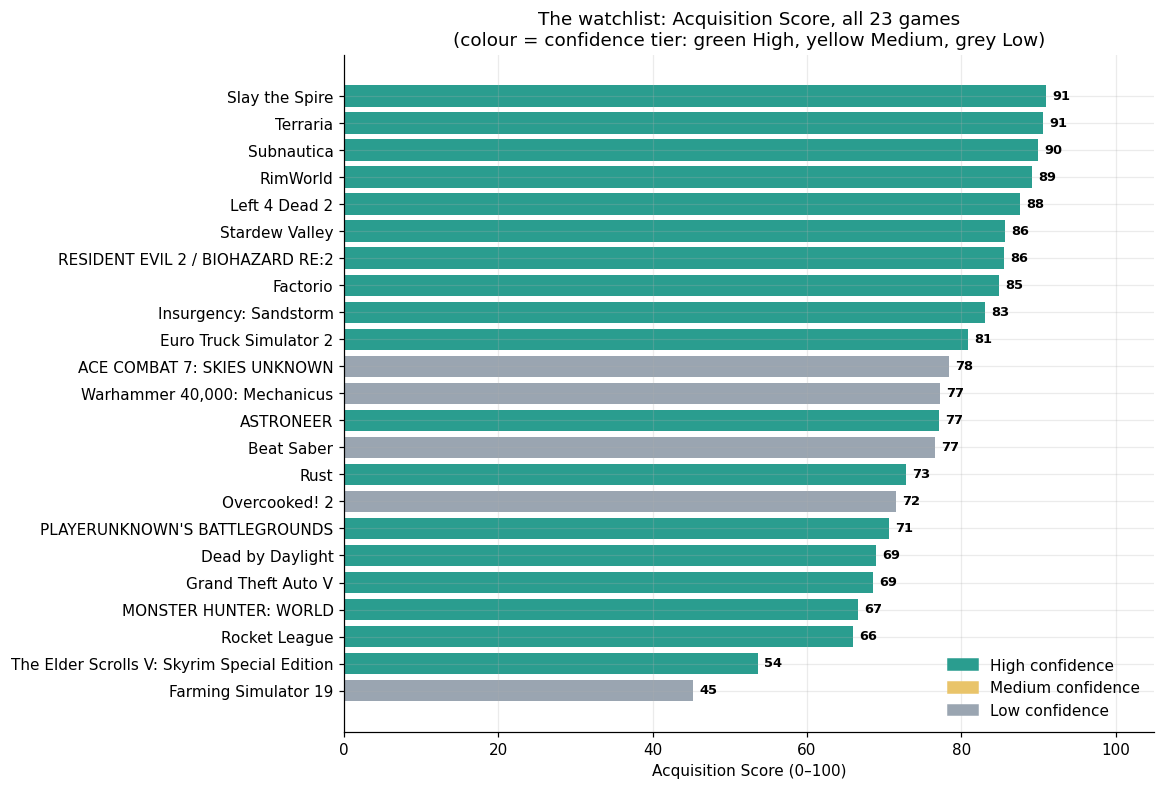

                                  score  conf    n   pos  momentum
title_clean                                                       
Slay the Spire                    91.05  High  231  0.99     17.92
Terraria                          90.56  High  239  1.00      0.12
Subnautica                        89.99  High  204  1.00      2.43
RimWorld                          89.17  High  184  1.00      0.86
Left 4 Dead 2                     87.58  High  202  1.00      2.91
Stardew Valley                    85.72  High  183  1.00      0.25
RESIDENT EVIL 2 / BIOHAZARD RE:2  85.58  High  496  0.99       NaN
Factorio                          84.87  High  158  1.00      0.20


In [3]:
ranked = g.sort_values('score', ascending=False)

fig, ax = plt.subplots(figsize=(9.5, 8))
colors = {'High': C_POS, 'Medium': C_HI, 'Low': C_MUT}
ax.barh(ranked.index, ranked['score'], color=[colors[c] for c in ranked['conf']])
for i, (t, r) in enumerate(ranked.iterrows()):
    ax.text(r['score'] + .8, i, f"{r['score']:.0f}", va='center', fontsize=8.5, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, 105)
ax.set_xlabel('Acquisition Score (0–100)')
ax.set_title('The watchlist: Acquisition Score, all 23 games\n(colour = confidence tier: green High, yellow Medium, grey Low)')
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=c, label=f'{k} confidence') for k, c in colors.items()],
          loc='lower right', frameon=False)
save(fig, '09_acquisition_ranking')
plt.show()
print(ranked[['score', 'conf', 'n', 'pos', 'momentum']].round(2).head(8).to_string())

saved figures/10_score_decomposition.png


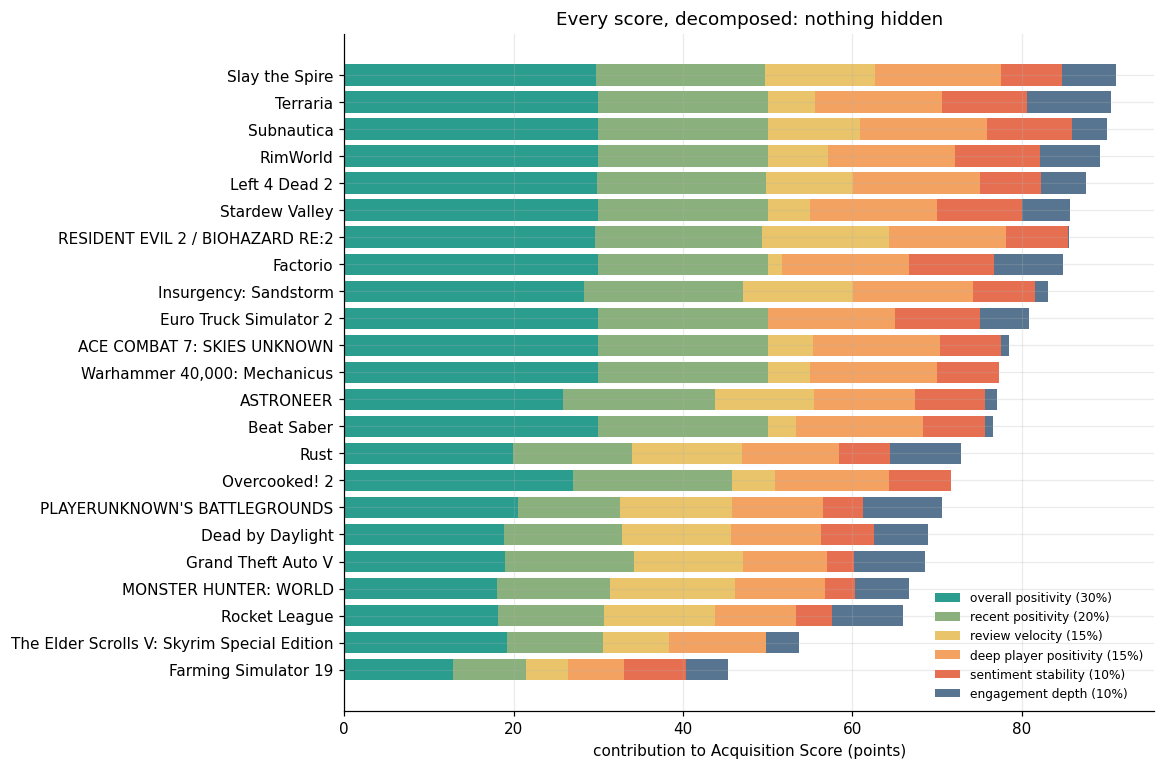

In [4]:
# Where does each game's score COME from? Full decomposition, no hidden parts.
contrib = comp.mul(pd.Series(WEIGHTS)) * 100
contrib = contrib.loc[ranked.index]

fig, ax = plt.subplots(figsize=(9.5, 8))
left = np.zeros(len(contrib))
for col, c in zip(comp.columns, COMP_COLORS):
    ax.barh(contrib.index, contrib[col], left=left, color=c,
            label=f"{col.replace('_', ' ')} ({WEIGHTS[col]:.0%})")
    left += contrib[col].values
ax.invert_yaxis()
ax.set_xlabel('contribution to Acquisition Score (points)')
ax.set_title('Every score, decomposed: nothing hidden')
ax.legend(loc='lower right', frameon=False, fontsize=8)
save(fig, '10_score_decomposition')
plt.show()

**What we found.** The combination does say something new. The podium isn't the most-positive
games (eight games are at 98–100%) and certainly isn't the biggest — it's the games where
*everything* holds at once: **Slay the Spire (91)** rides momentum on top of near-perfect
sentiment; **Terraria (91), Subnautica (90), RimWorld (89)** are the evergreen profile —
loved, stable, deeply played for years. The decomposition shows their bars are *balanced*;
no single component carries them.

The mega-titles tell the opposite story: PUBG, GTA V, Rocket League, Dead by Daylight land at
**66–73** despite enormous audiences, dragged by mediocre sentiment and instability — and as
multi-thousand-review giants they're unrealistic targets for a small publisher anyway. The score
agrees with common sense *for visible reasons*, which is the entire point of building it this
way. At the bottom of the high-confidence pack: **Skyrim SE (54)**, hit simultaneously on
stability (the paid-mods quarter), recent sentiment, and velocity.

## Question 3 — Is the ranking an artefact of my weights?

1. **Jitter:** redraw every weight uniformly within ±50% of its value (renormalised), 2,000
   times; watch where each game's rank lands.
2. **Amputation:** delete each component entirely, renormalise the rest, correlate the new
   ranking with the original.
3. **No judgement at all:** equal weights.

saved figures/11_weight_sensitivity.png


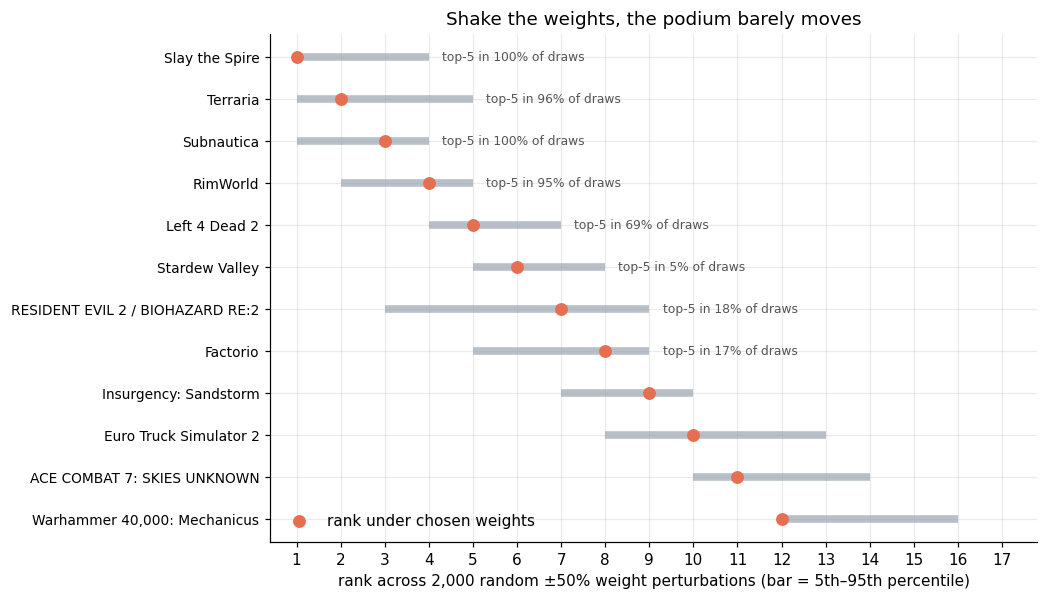

In [5]:
rng = np.random.default_rng(SEED)
N_DRAWS = 2000
w0 = np.array([WEIGHTS[c] for c in comp.columns])
rank_draws = np.zeros((N_DRAWS, len(comp)))
for i in range(N_DRAWS):
    w = w0 * rng.uniform(0.5, 1.5, size=len(w0)); w /= w.sum()
    rank_draws[i] = pd.Series(comp.values @ w, index=comp.index).rank(ascending=False).values
rk = pd.DataFrame(rank_draws, columns=comp.index)

base_rank = g['score'].rank(ascending=False)
sens = pd.DataFrame({'base': base_rank, 'p5': rk.quantile(.05), 'p95': rk.quantile(.95),
                     'top5_share': (rk <= 5).mean()}).sort_values('base')

TOP = 12
top = sens.head(TOP)
fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(TOP)
ax.hlines(y, top['p5'], top['p95'], color=C_MUT, lw=5, alpha=.7)
ax.scatter(top['base'], y, color=C_NEG, zorder=5, s=55, label='rank under chosen weights')
for i, (t, r) in enumerate(top.iterrows()):
    if r['top5_share'] >= 0.005:
        ax.text(r['p95'] + .3, i, f"top-5 in {r['top5_share']:.0%} of draws",
                va='center', fontsize=8, color='#555')
ax.set_yticks(y); ax.set_yticklabels(top.index, fontsize=9)
ax.invert_yaxis()
xmax = int(top['p95'].max()) + 1
ax.set_xticks(range(1, xmax + 1)); ax.set_xlim(0.4, xmax + 0.8)
ax.set_xlabel(f'rank across {N_DRAWS:,} random ±50% weight perturbations (bar = 5th–95th percentile)')
ax.set_title('Shake the weights, the podium barely moves')
ax.legend(loc='lower left', frameon=False)
save(fig, '11_weight_sensitivity')
plt.show()

In [6]:
print("Amputation test — delete a component, renormalise, correlate with base ranking:")
base_score = g['score']
for c in comp.columns:
    w2 = {k: v for k, v in WEIGHTS.items() if k != c}
    tot = sum(w2.values())
    s2 = sum(comp[k] * (v / tot) for k, v in w2.items())
    print(f"  without {c:24s} Spearman rho = {spearmanr(base_score, s2).statistic:.3f}")
print(f"\nEqual weights (no judgement at all): rho = {spearmanr(base_score, comp.mean(axis=1)).statistic:.3f}")

Amputation test — delete a component, renormalise, correlate with base ranking:
  without overall_positivity       Spearman rho = 0.875
  without recent_positivity        Spearman rho = 0.956
  without review_velocity          Spearman rho = 0.897
  without deep_player_positivity   Spearman rho = 0.988
  without sentiment_stability      Spearman rho = 0.983
  without engagement_depth         Spearman rho = 0.944

Equal weights (no judgement at all): rho = 0.927


**What we found.** The ranking is robust to the judgement calls inside it. Across 2,000
random ±50% weight perturbations, **the top four (Slay the Spire, Terraria, Subnautica,
RimWorld) sit in the top five in 95–100% of draws**. Deleting *entire components* never drops
rank correlation below **0.88**; equal weights — no judgement at all — still correlates **0.93**
with the chosen ranking. The weights shape margins, not conclusions.


## Question 4 — What *kind* of game is each, and whose negativity wouldn't transfer?


In [7]:
def archetype(r):
    if r['conf'] == 'Low':                                                return 'Insufficient Data'
    if r['age_days'] <= 180:                                              return 'New Release (Unproven)'
    if (r['momentum'] >= 3) and (r['pos'] >= .90):                        return 'Rising Star'
    if (r['recent_pos_adj'] <= r['pos'] - .05) and (r['recent_n']/r['n'] < .05):  return 'Declining'
    if (r['n'] >= 1000) and (r['pos'] < .80):                             return 'Volatile Giant'
    if (r['age_days'] >= 913) and (r['pos'] >= .95):                      return 'Evergreen'  # 2.5+ years
    if r['pos'] >= .80:                                                   return 'Solid Performer'
    return 'Contested'
g['archetype'] = g.apply(archetype, axis=1)

# Protest-quarter flag: same method as the Step 2 anomaly scan, hard-threshold for the scorecard.
# A game is flagged when some quarter (>= 50 reviews, with >= 4 such quarters to define "normal")
# sits >= 30 points below the game's own median quarter.
protest = {}
for t, sub in df.groupby('title_clean'):
    q = sub.set_index('date')['rec'].resample('QE').agg(n='size', pos='mean')
    q = q[q['n'] >= 50]
    if len(q) < 4:
        protest[t] = (False, '', np.nan); continue
    dev = q['pos'] - q['pos'].median()
    worst = dev.idxmin()
    protest[t] = (dev.min() <= -0.30, str(worst.to_period('Q')) if dev.min() <= -0.30 else '', dev.min())
g['protest_flag']    = pd.Series({k: v[0] for k, v in protest.items()})
g['protest_quarter'] = pd.Series({k: v[1] for k, v in protest.items()})

# NLP context: dominant complaint & praise per game, publisher-conduct share
comp_cols   = [c for c in sig.columns if c.startswith('complaint:')]
praise_cols = [c for c in sig.columns if c.startswith('praise:')]
# (small games have all-NaN theme shares — Step 3 declined to compute percentages on n < 20)
has_c = sig[comp_cols].notna().any(axis=1)
has_p = sig[praise_cols].notna().any(axis=1)
g['top_complaint'] = pd.Series('', index=g.index, dtype=object)
g.loc[has_c, 'top_complaint'] = sig.loc[has_c, comp_cols].idxmax(axis=1).str.replace('complaint: ', '')
g['top_complaint_share'] = sig[comp_cols].max(axis=1)
g['top_praise'] = pd.Series('', index=g.index, dtype=object)
g.loc[has_p, 'top_praise'] = sig.loc[has_p, praise_cols].idxmax(axis=1).str.replace('praise: ', '')
g['publisher_conduct_share'] = sig['complaint: publisher conduct']
g['text_pos_mean'] = sig['text_pos_mean']

view = (g.sort_values('score', ascending=False)
          [['score', 'conf', 'archetype', 'protest_flag', 'protest_quarter',
            'top_complaint', 'top_complaint_share']])
print(view.round(2).to_string())

                                             score  conf               archetype  protest_flag protest_quarter           top_complaint  top_complaint_share
title_clean                                                                                                                                                
Slay the Spire                               91.05  High             Rising Star         False                                                          NaN
Terraria                                     90.56  High               Evergreen         False                                                          NaN
Subnautica                                   89.99  High               Evergreen         False                                                          NaN
RimWorld                                     89.17  High               Evergreen         False                                                          NaN
Left 4 Dead 2                                87.58  High        

**What we found.** The rules reproduce the catalogue's intuitive structure without a single
hand-label: seven **Evergreens** (Terraria, RimWorld, Stardew, Factorio, Subnautica, Euro Truck,
L4D2), one **Rising Star** (Slay the Spire, the only game clearing 3x momentum at 90%+
positivity), five **Volatile Giants**, two **New Releases** (RE2, Insurgency — strong launches,
no track record), one **Declining** (Skyrim SE: sentiment below its own lifetime level *and*
review flow drying up), plus a Solid Performer (ASTRONEER), a Contested entry (Monster Hunter:
World — itself a port with connectivity problems, a cautionary tale precisely in GameVault's
line of business), and five games with too little data to say anything honest.

## Outputs for Step 5 — the scorecard

In [8]:
scorecard = g.sort_values('score', ascending=False).copy()
scorecard['rank'] = range(1, len(scorecard) + 1)
for c in comp.columns:                       # normalised components, for dashboard sliders
    scorecard[f'c_{c}'] = comp[c]
cols = (['rank', 'score', 'conf', 'archetype', 'n', 'pos', 'recent_n', 'recent_pos_adj',
         'momentum', 'deep_pos_adj', 'median_hours', 'q_pos_std', 'stability_unmeasured',
         'protest_flag', 'protest_quarter', 'text_pos_mean',
         'top_complaint', 'top_complaint_share', 'top_praise', 'publisher_conduct_share']
        + [f'c_{c}' for c in comp.columns])
scorecard = scorecard[cols]
scorecard.to_csv('data/acquisition_scorecard.csv', index_label='title_clean')
print('saved data/acquisition_scorecard.csv', scorecard.shape)
scorecard.head(10).round(2)

saved data/acquisition_scorecard.csv (23, 26)


,rank,score,conf,archetype,n,pos,recent_n,recent_pos_adj,momentum,deep_pos_adj,...,top_complaint,top_complaint_share,top_praise,publisher_conduct_share,c_overall_positivity,c_recent_positivity,c_review_velocity,c_deep_player_positivity,c_sentiment_stability,c_engagement_depth
title_clean,,,,,,,,,,,,,,,,,,,,,
Slay the Spire,1,91.05,High,Rising Star,231,0.99,215,1.00,17.92,0.99,...,,NaN,fun & enjoyment,NaN,0.99,1.00,0.87,0.99,0.73,0.63
Terraria,2,90.56,High,Evergreen,239,1.00,9,1.00,0.12,1.00,...,,NaN,fun & enjoyment,NaN,1.00,1.00,0.37,1.00,1.00,1.00
Subnautica,3,89.99,High,Evergreen,204,1.00,90,1.00,2.43,1.00,...,,NaN,story & world,NaN,1.00,1.00,0.73,1.00,1.00,0.41
RimWorld,4,89.17,High,Evergreen,184,1.00,18,1.00,0.86,1.00,...,,NaN,story & world,NaN,1.00,1.00,0.47,1.00,1.00,0.71
Left 4 Dead 2,5,87.58,High,Evergreen,202,1.00,67,1.00,2.91,1.00,...,,NaN,friends & social,NaN,1.00,1.00,0.68,1.00,0.73,0.53
Stardew Valley,6,85.72,High,Evergreen,183,1.00,7,1.00,0.25,1.00,...,,NaN,fun & enjoyment,NaN,1.00,1.00,0.33,1.00,1.00,0.57
RESIDENT EVIL 2 / BIOHAZARD RE:2,7,85.58,High,New Release (Unproven),496,0.99,496,0.99,NaN,0.92,...,,NaN,value for money,NaN,0.99,0.99,1.00,0.92,0.73,0.02
Factorio,8,84.87,High,Evergreen,158,1.00,1,1.00,0.20,1.00,...,,NaN,fun & enjoyment,NaN,1.00,1.00,0.11,1.00,1.00,0.82
Insurgency: Sandstorm,9,83.03,High,New Release (Unproven),208,0.94,208,0.94,NaN,0.95,...,,NaN,fun & enjoyment,NaN,0.94,0.94,0.86,0.95,0.73,0.15


## Summary — what we found, and where it goes next

| # | Question we asked | Answer the data gave | Number to remember |
|---|---|---|---|
| 1 | What should the score reward? | Six components, each with an evidence trail; volume deliberately excluded from the number | 30/20/15/15/10/10, documented |
| 2 | What does the ranking say? | Balanced excellence beats both perfection-on-one-axis and raw size | Slay the Spire 91, Terraria 91, Subnautica 90, RimWorld 89; giants 66–73; Skyrim SE 54 |
| 3 | Do the weights drive the answer? | No — the podium survives ±50% jitter, component deletion, and equal weights | top-4 in top-5 in 95–100% of 2,000 draws; worst-case rho 0.88 |
| 4 | What kind of game is each? | Rule-based archetypes + protest flags reproduce, and extend, the Step 2/3 findings | 2 protest flags (GTA V, Skyrim SE), both 61% publisher-conduct complaints |

